# PPE Detection for Industry 5.0 — Dataset Exploration

**Construction Site Safety** dataset (Roboflow, v30) · YOLOv8 format


## 1. Setup

Adding Roboflow API key

In [1]:
!pip install -q roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.9 MB/s eta 0:00:00


In [3]:
from roboflow import Roboflow

# Read the key from a Colab secret (falls back to a prompt if not on Colab)
try:
    from google.colab import userdata
    api_key = userdata.get('ROBOFLOW_API_KEY')
except Exception:
    import getpass
    api_key = getpass.getpass('Roboflow API key: ')

rf = Roboflow(api_key=api_key)
project = rf.workspace("roboflow-universe-projects").project("construction-site-safety")
version = project.version(30)
dataset = version.download("yolov8")
print("Downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Construction-Site-Safety-30 in yolov8:: 100%|██████████| 1446/1446 [00:00<00:00, 4810.97it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Downloaded to: /content/Construction-Site-Safety-30


## 2. Inspect classes

In [4]:
import yaml
from pathlib import Path

root = Path(dataset.location)
with open(root / "data.yaml") as f:
    cfg = yaml.safe_load(f)

names = cfg["names"]
# Roboflow exports names as a list; normalize just in case
class_names = list(names.values()) if isinstance(names, dict) else list(names)

print("Number of classes:", len(class_names))
for i, n in enumerate(class_names):
    print(f"{i:2d}  {n}")

Number of classes: 25
 0  Excavator
 1  Gloves
 2  Hardhat
 3  Ladder
 4  Mask
 5  NO-Hardhat
 6  NO-Mask
 7  NO-Safety Vest
 8  Person
 9  SUV
10  Safety Cone
11  Safety Vest
12  bus
13  dump truck
14  fire hydrant
15  machinery
16  mini-van
17  sedan
18  semi
19  trailer
20  truck and trailer
21  truck
22  van
23  vehicle
24  wheel loader


## 3. Count images per split

In [5]:
for split in ["train", "valid", "test"]:
    img_dir = root / split / "images"
    if img_dir.exists():
        n = len(list(img_dir.glob("*.*")))
        print(f"{split:6s}: {n:5d} images")

train :   521 images
valid :   114 images
test  :    82 images


## 4. Visualize annotated samples



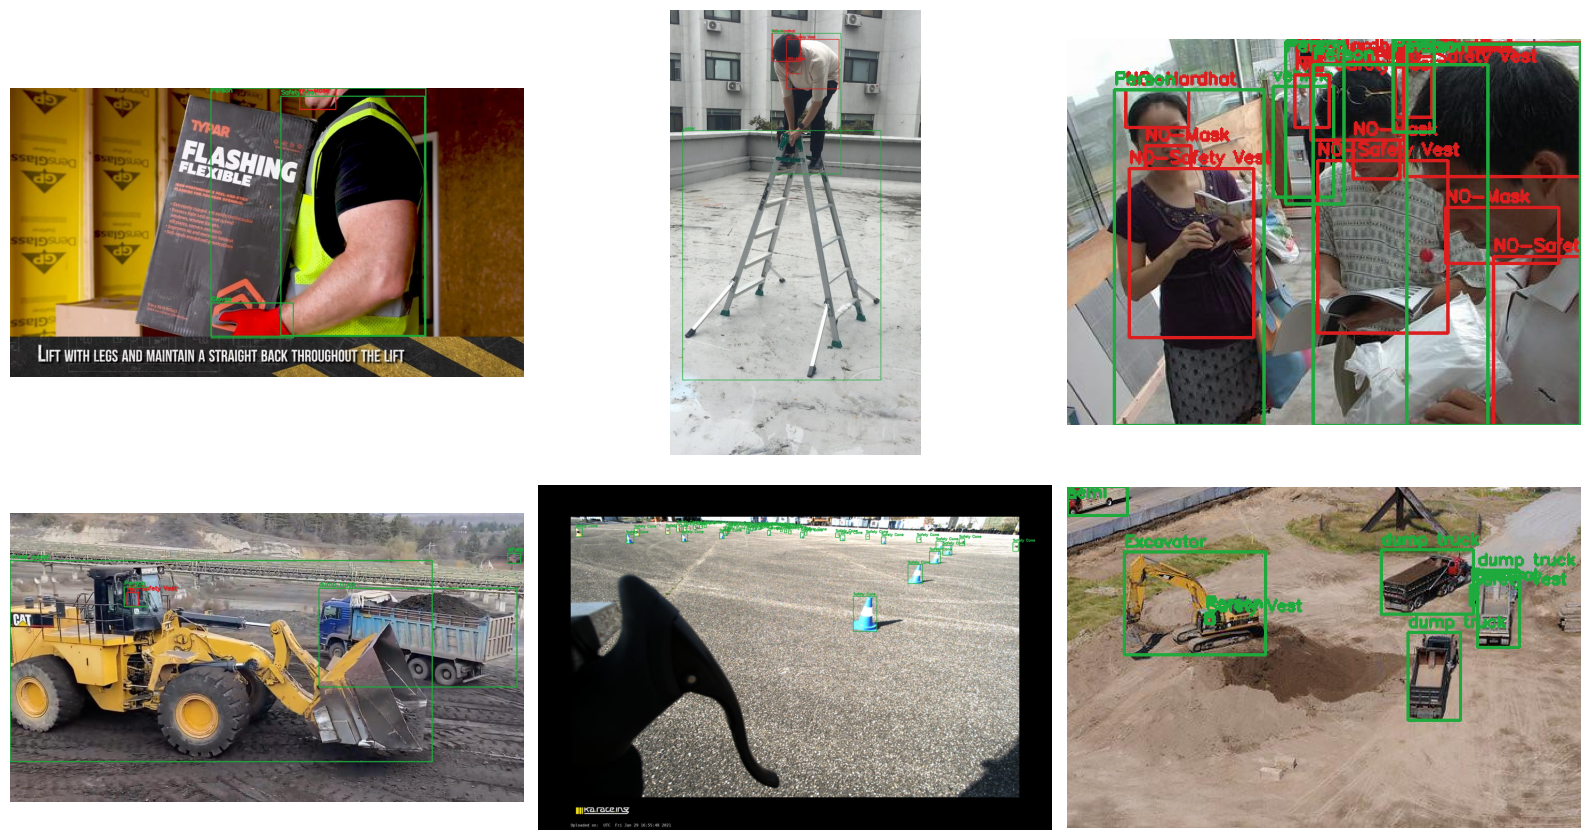

In [6]:
import cv2, random
import matplotlib.pyplot as plt

def load_label(label_path):
    boxes = []
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            if not line:
                continue
            p = line.split()
            cls = int(p[0])
            cx, cy, w, h = map(float, p[1:5])
            boxes.append((cls, cx, cy, w, h))
    return boxes

def annotated(img_path):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    lbl = Path(str(img_path).replace("/images/", "/labels/")).with_suffix(".txt")
    for cls, cx, cy, w, h in load_label(lbl):
        x1, y1 = int((cx - w / 2) * W), int((cy - h / 2) * H)
        x2, y2 = int((cx + w / 2) * W), int((cy + h / 2) * H)
        miss = class_names[cls].upper().startswith("NO")
        color = (220, 30, 30) if miss else (30, 170, 60)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, class_names[cls], (x1, max(y1 - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return img

train_imgs = list((root / "train" / "images").glob("*.*"))
random.seed(0)
samples = random.sample(train_imgs, min(6, len(train_imgs)))

plt.figure(figsize=(16, 9))
for i, p in enumerate(samples):
    plt.subplot(2, 3, i + 1)
    plt.imshow(annotated(p))
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Class balance

Counts every annotation in the training split. Imbalance here is normal
(Person and Hardhat dominate; NO-* and Mask are rarer) and affects how to read
per-class mAP later. Note this in the report - it is part of the grade.

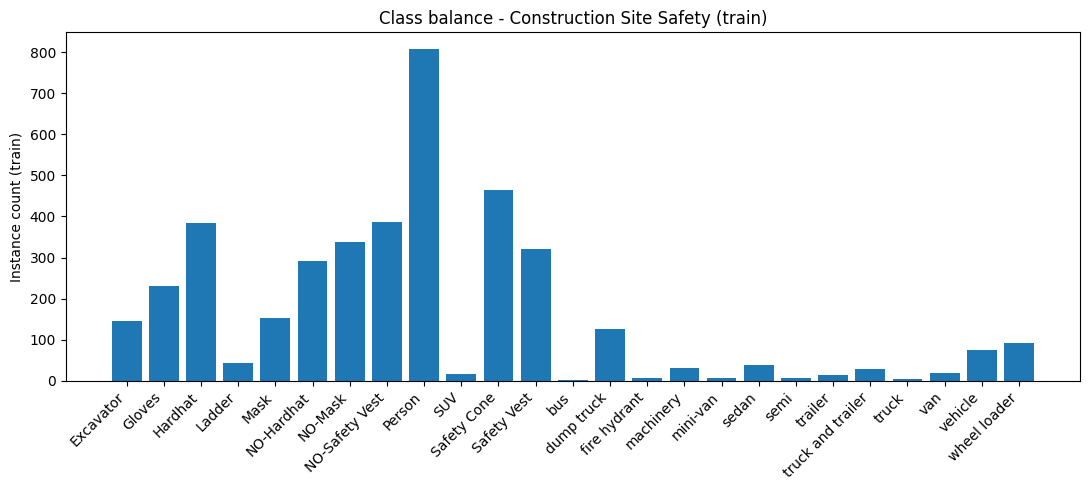

Instances per class (train, descending):
  Person             808
  Safety Cone        464
  NO-Safety Vest     386
  Hardhat            385
  NO-Mask            338
  Safety Vest        322
  NO-Hardhat         292
  Gloves             231
  Mask               153
  Excavator          145
  dump truck         127
  wheel loader       93
  vehicle            74
  Ladder             43
  sedan              39
  machinery          31
  truck and trailer  29
  van                18
  SUV                16
  trailer            13
  semi               7
  fire hydrant       6
  mini-van           6
  truck              4
  bus                1


In [7]:
from collections import Counter

counts = Counter()
for lbl in (root / "train" / "labels").glob("*.txt"):
    for line in lbl.read_text().strip().splitlines():
        if line:
            counts[int(line.split()[0])] += 1

labels = [class_names[i] for i in range(len(class_names))]
values = [counts.get(i, 0) for i in range(len(class_names))]

plt.figure(figsize=(11, 5))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Instance count (train)")
plt.title("Class balance - Construction Site Safety (train)")
plt.tight_layout()
plt.show()

print("Instances per class (train, descending):")
for n, v in sorted(zip(labels, values), key=lambda x: -x[1]):
    print(f"  {n:18s} {v}")

## Observations
- Total images per split: _717_
- Most frequent classes: _Person_
- Rarest classes : _bus_
- Imbalance strategy: rely on YOLOv8 built-in augmentation; consider more
  epochs and interpret per-class AP rather than only overall mAP.

**Next phase:** fine-tune `yolov8s.pt` on this dataset.